In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import numpy as np
from echofit.echofit import EchoFit

/Users/david/Library/Caches/pypoetry/virtualenvs/echofit-W-NSutmR-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Create an echofit instance

In [3]:
fit = EchoFit(M_BH=1e8)


# Data Ingestion

In [4]:
fit.add_lightcurve_csv("../data/uv.csv", wavelength=2000.0)
fit.add_lightcurve_csv("../data/optical.csv", wavelength=5000.0)

# Plot raw light curves

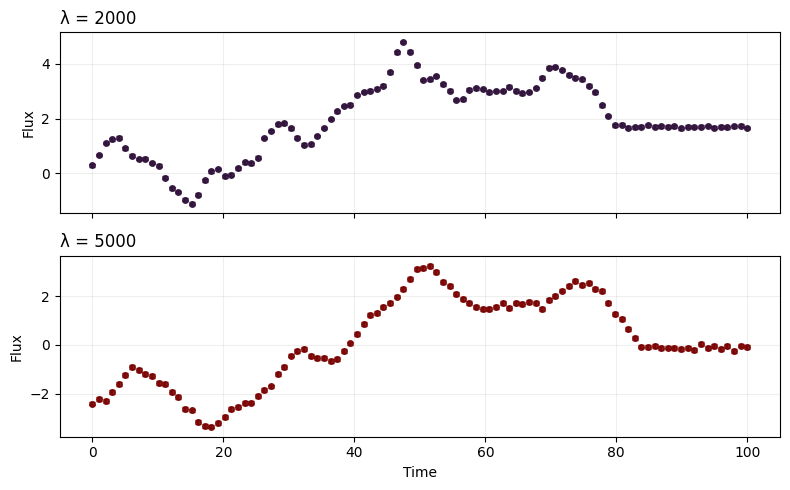

In [5]:
fit.plot_raw_lightcurve_data()

# Run

In [6]:
fit.fit(num_warmup=20, num_samples=40, fixed_params={'inclination':0.0,'log_sigma':0.0})

sample: 100%|██████████| 60/60 [00:28<00:00,  2.11it/s, 71 steps of size 7.32e-02. acc. prob=0.40]  


# Convergence Diagnostics

In [7]:
samples = fit.mcmc.get_samples()

for k in samples:
    print(k, np.mean(samples[k]), np.std(samples[k]))

C_0 1.4412537 0.52898693
C_1 -0.3594103 0.5278582
S_0 0.39567605 4.3295555
S_1 0.62730974 3.8512115
log_mdot -0.11894655 0.92127407
log_tau_drw 3.8066208 0.10964674
loglike -3149.5137 0.7036937


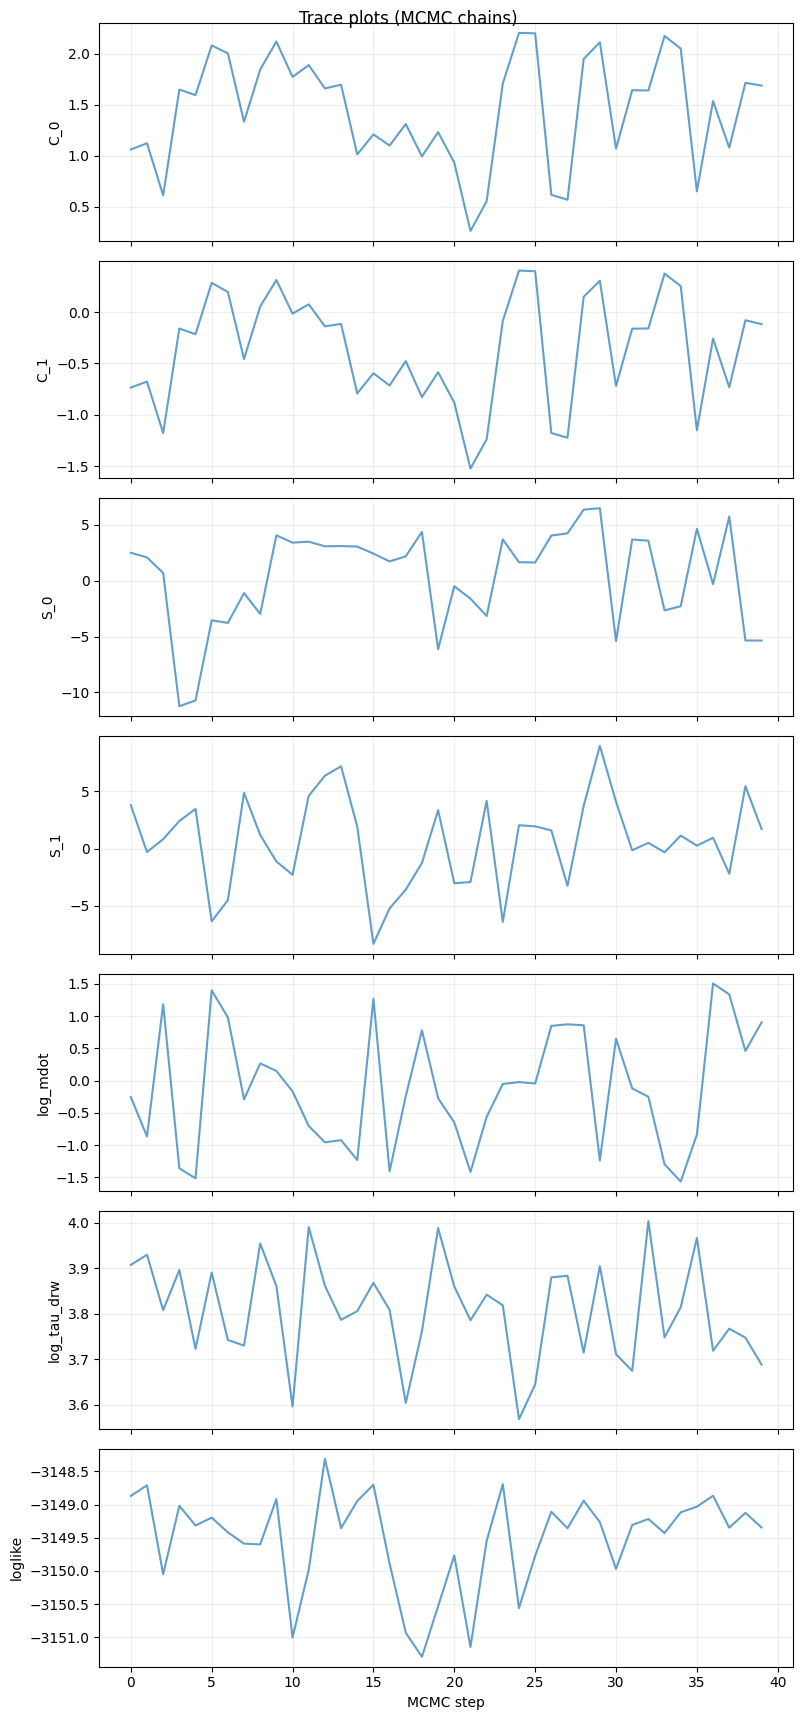

In [8]:
#fit.plot_trace()
#fit.summary()
fit.plot_mcmc_diagnostics()


# Posterior Dstributions

In [9]:
#fit.plot_posterior()

# Light curve fits

In [10]:
fit.fixed_params

{'inclination': 0.0, 'log_sigma': 0.0}

In [11]:
#fit.mcmc.get_samples()

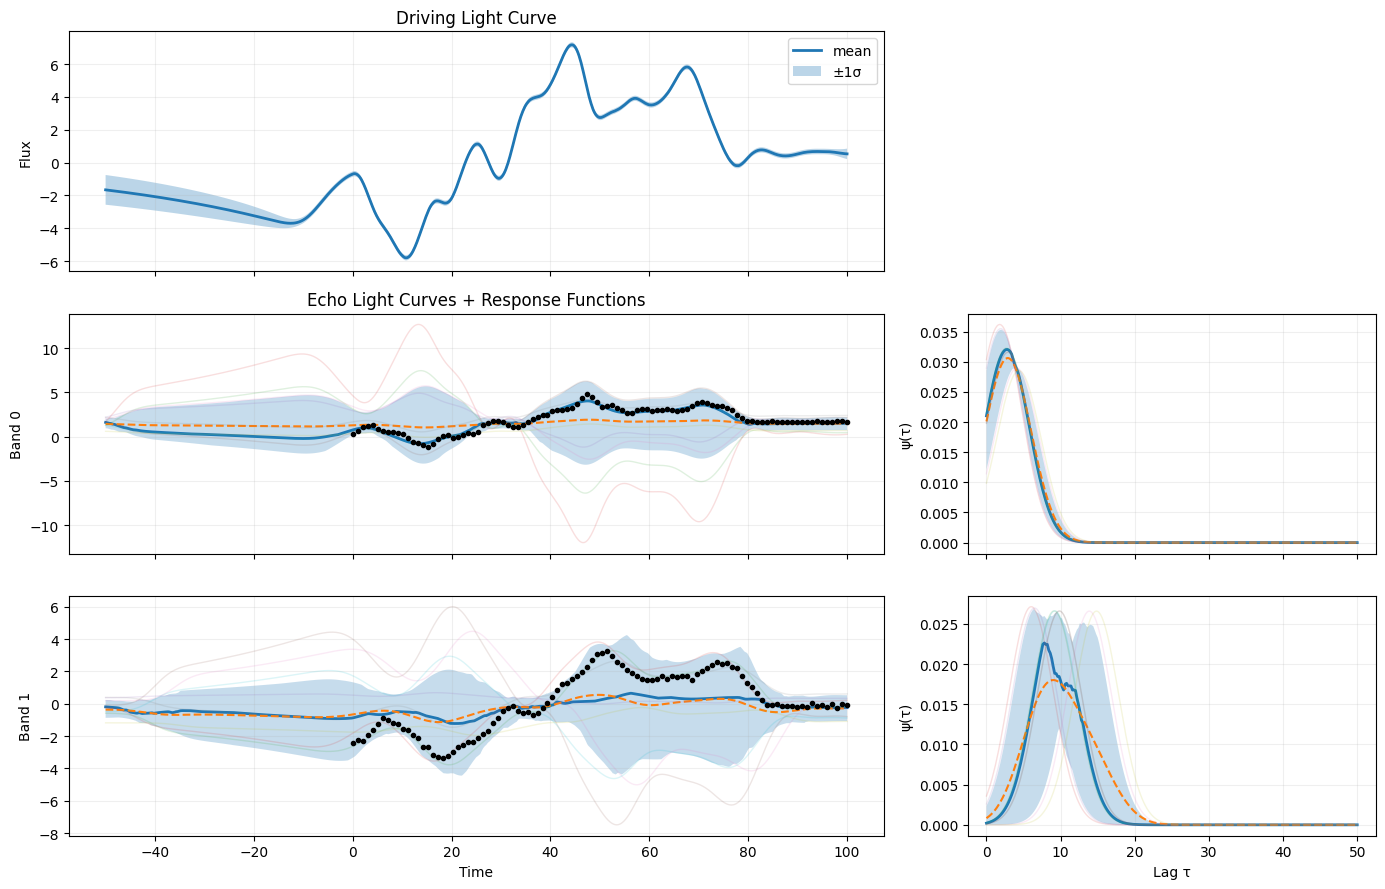

In [12]:
fit.plot_lightcurve_fits()

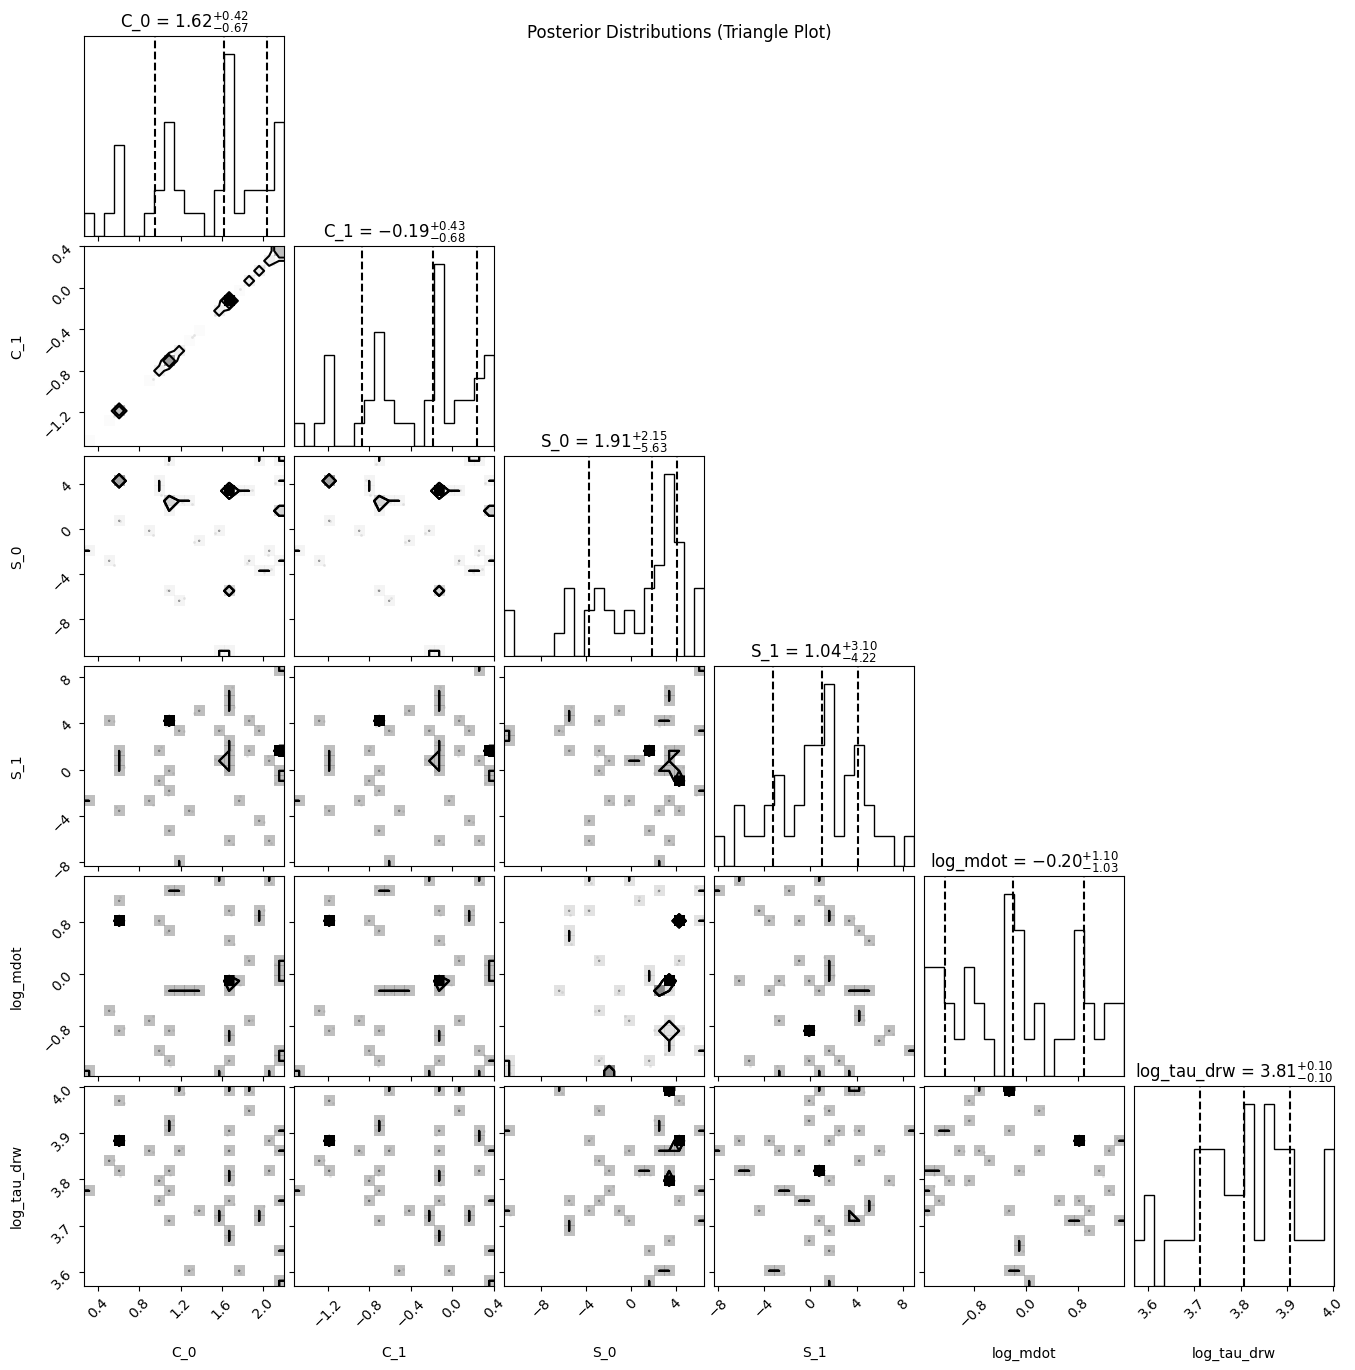

In [13]:
fit.plot_triangle()

# Plot power spectrum of driver and BOF

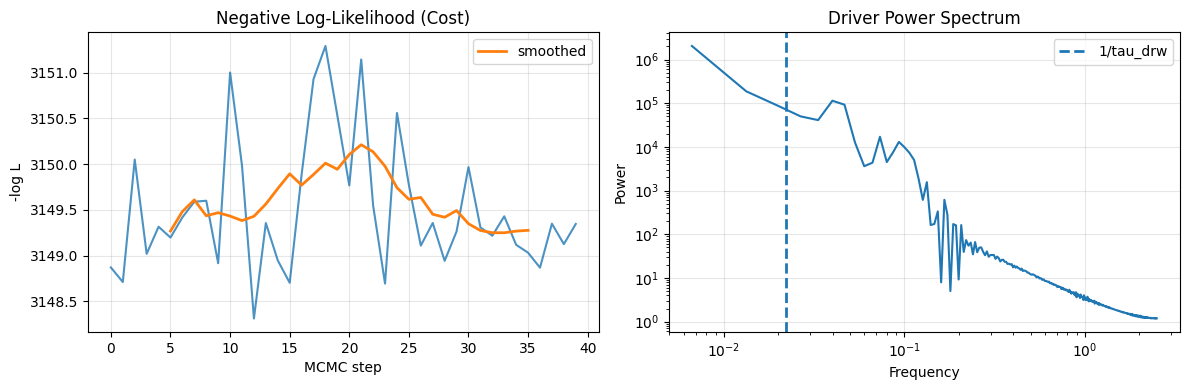

In [14]:
fit.plot_extended_diagnostics()

# Appendix

## Test response function

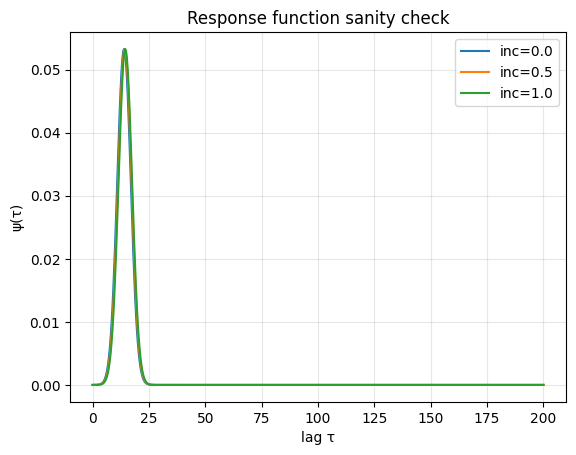

mu = 13.956125
sigma = 4.1868377
skew = 0.7615941559557649
tau range = 0.0 200.0


In [15]:
import numpy as np
import matplotlib.pyplot as plt

from echofit.forward_model import build_response_function, lag_scaling

tau_grid = np.linspace(0, 200, 500)

M_BH = 1e8  # fixed mass

log_mdot = 1.0
wavelength = 5000.0

for inc in [0.0, 0.5, 1.0]:

    psi = build_response_function(
        tau_grid,
        log_mdot,
        wavelength,
        inc,
        M_BH,
    )

    plt.plot(tau_grid, psi, label=f"inc={inc}")

plt.xlabel("lag τ")
plt.ylabel("ψ(τ)")
plt.title("Response function sanity check")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

mu = lag_scaling(log_mdot, wavelength, M_BH)

sigma = 0.3 * mu
skew = np.tanh(inc)

print("mu =", mu)
print("sigma =", sigma)
print("skew =", skew)
print("tau range =", tau_grid.min(), tau_grid.max())